# 数据处理1-消费数据

In [46]:
import pandas as pd
# 读取Excel文件
df_person = pd.read_csv("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2020\\cfps2020person_202306.csv")
#读取Excel文件
df_family = pd.read_excel("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2020\\cfps2020famecon_202306.xlsx")

C:\Users\admin\AppData\Local\Temp\ipykernel_25200\3997362148.py:3: DtypeWarning: Columns (3,9,27,30,36,61,62,69,251,268,287,456,1097,1098,1099,1100,1101) have mixed types. Specify dtype option on import or set low_memory=False.
  df_person = pd.read_csv("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2020\\cfps2020person_202306.csv")


## 描述性统计

## 直方图和密度图
Seaborn允许你将直方图和密度图结合在一起，这样可以更直观地看到数据的分布情况和密度估计。

Text(0, 0.5, 'Density')

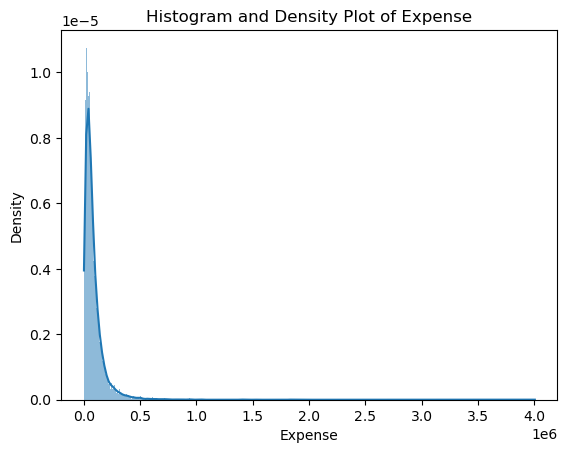

In [39]:

import seaborn as sns
import matplotlib.pyplot as plt
# 使用seaborn绘制直方图和密度图
sns.histplot(df_family['expense'], kde=True, stat="density", linewidth=0)

# 设置图形的标题和标签
plt.title('Histogram and Density Plot of Expense')
plt.xlabel('Expense')
plt.ylabel('Density')


分位数是统计学中用来描述数据分布的一个概念，它表示将数据集分成若干等份的数值。分位数可以帮助我们了解数据的分布情况，尤其是在数据量较大或者数据分布不均匀时。以下是一些常见的分位数及其定义：

* 最小值（Min）：数据集中最小的数值，可以看作是0%的分位数。

* 第一四分位数（Q1，25%分位数）：将数据集从小到大排序后，位于25%位置的数值。这意味着25%的数据项小于或等于这个值。

* 中位数（Q2，50%分位数）：数据集的中间值，即50%的分位数。如果数据集的元素个数是奇数，中位数就是中间的那个数；如果是偶数，则是中间两个数的平均值。

* 第三四分位数（Q3，75%分位数）：位于75%位置的数值，表示75%的数据项小于或等于这个值。

* 最大值（Max）：数据集中最大的数值，可以看作是100%的分位数。

```df_family['expense']```的缺失值

In [ ]:
import numpy as np
data = np.array([1, 2, 2, 3, 4, 5, 5, 5, 6, 7])
Q1 = np.percentile(data, 25)  # 第一四分位数
Q2 = np.percentile(data, 50)  # 中位数
Q3 = np.percentile(data, 75)  # 第三四分位数

print(f"第25百分位数（Q1）: {Q1}")
print(f"中位数（Q2）: {Q2}")
print(f"第75百分位数（Q3）: {Q3}")

第25百分位数（Q1）: 2.25
中位数（Median）: 4.5
第75百分位数（Q3）: 5.0


In [57]:
import pandas as pd

# 创建数据字典
data = {
    'expense': [200, 150, np.nan, 250, 180],
    'income': [250, 200, 350, 300, 220]
}

# 创建DataFrame
data = pd.DataFrame(data)

# 显示DataFrame
print(data)
data = data.dropna(subset=['expense'])
np.percentile(data , 50)

   expense  income
0    200.0     250
1    150.0     200
2      NaN     350
3    250.0     300
4    180.0     220


210.0

In [96]:

df_family = df_family.dropna(subset=['expense'])

# 计算第5百分位数和第99百分位数
Q1 = np.percentile(df_family["expense"], 1)
print(Q1)
Q99 = np.percentile(df_family["expense"], 90)
print(Q99)
# 使用布尔索引过滤掉超出[Q1, Q99]范围的值
df_family = df_family.dropna(subset=['expense'])
df_family_99 = df_family[(df_family["expense"] >= Q1) & (df_family["expense"] <= Q99)]

3500.0
172618.00000000006


Text(0, 0.5, 'Density')

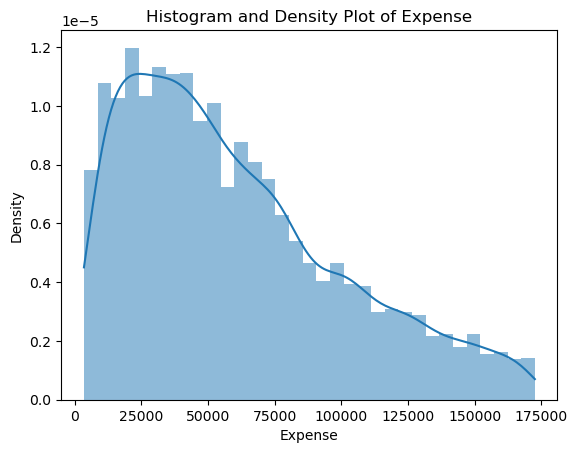

In [54]:
# 使用seaborn绘制直方图和密度图
sns.histplot(df_family_99['expense'], kde=True, stat="density", linewidth=0)

# 设置图形的标题和标签
plt.title('Histogram and Density Plot of Expense')
plt.xlabel('Expense')
plt.ylabel('Density')

In [7]:
from scipy import stats

# 使用scipy计算描述性统计信息
desc_stats = stats.describe(df_family_99['expense'])

# 打印描述性统计信息
print(f"Count: {desc_stats.nobs}")
print(f"Mean: {desc_stats.mean:.3f}")
print(f"Variance: {desc_stats.variance:.3f}")
print(f"Min: {desc_stats.minmax[0]:.3f}")
print(f"Max: {desc_stats.minmax[1]:.3f}")

Count: 10198
Mean: 60170.845
Variance: 1647746419.223
Min: 3500.000
Max: 172600.000


Text(0, 0.5, 'Density')

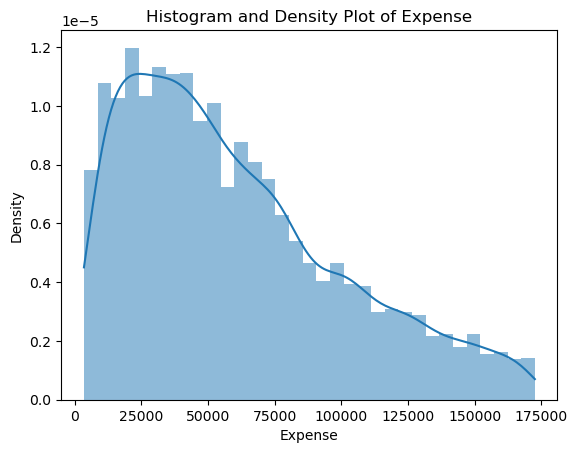

In [8]:
# 使用seaborn绘制直方图和密度图
sns.histplot(df_family_99['expense'], kde=True, stat="density", linewidth=0)

# 设置图形的标题和标签
plt.title('Histogram and Density Plot of Expense')
plt.xlabel('Expense')
plt.ylabel('Density')


In [30]:
print(df_family_99)

         fid20    fid18   fid16   fid14   fid12   fid10 provcd20  countyid20  \
0       100051   100051  100051  100051  110043  110043      北京市        45.0   
2       100286   100286  100286  100286  130005  130005      河北省       239.0   
3       100376   100376  100376  100376  130094  130094      河北省       235.0   
4       100435   100435  100435  100435  130155  130155      河北省        52.0   
5       100453   100453  100453  100453  100453  430111      湖南省        29.0   
...        ...      ...     ...     ...     ...     ...      ...         ...   
11615  6694541  6694541  211229  211229  211229  211229   内蒙古自治区       592.0   
11616  6704011  6704011  220306  220306  220306  220306      吉林省        59.0   
11617  6759191  6759191  410650  410650  410650  410650      河南省       105.0   
11618  6769401   620012  620012  620012  620012  620012      北京市       176.0   
11619  6929111   450020  450020  450020  450020  450020      广东省       127.0   

          cid20 urban20  ... total_asse

### 计算消费分类
#### 国家统计局的消费分类
https://data.stats.gov.cn/easyquery.htm?cn=E0101

#### 消费分类
| 一级消费类型   | 二级消费类型 | cfps2020 |
|----------------|--------------|----------|
| 生存型消费     | 食品消费     | food     |
|                | 居住消费     | house    |
|                | 衣着消费     | dress    |
| 发展享受型消费 | 文教娱乐     | eec      |
|                | 医疗保健     | med      |
|                | 交通通信     | trco     |
|                | 家庭设备及用品 | daily    |
|                | 其他用品及服务 | other    |
| 耐用品消费     | 住房维修费   | FP506    |
|                | 汽车购置     | FP507N   |
|                | 交通通信设备 | FP508    |
|                | 家具耐用品   | FP509    |
| 总消费         |              | pce      |


## 清理数据，数据中可能有缺失，不适用，不知道，数据类型不对

In [ ]:
missing_food = df_family_99[df_family_99['food'].isnull()]
print(missing_food)


        fid20   fid18   fid16   fid14   fid12   fid10 provcd20  countyid20  \
259    123392  123392  123392  320219  320219  320219      江苏省        11.0   
276    126209  126209  126209  411168  411168  411168      湖北省      1750.0   
389    130149  130149  130149  130149  130149  130149      河北省        52.0   
476    130351  130351  130351  130351  130351  130351      河北省        49.0   
502    130426  130426  130426  130426  130426  130426      河北省        49.0   
...       ...     ...     ...     ...     ...     ...      ...         ...   
11037  638824  638824  370076  370076  370076  370076      山东省        67.0   
11135  652721  440273  440273  440273  440273  440273  广西壮族自治区       356.0   
11287  673163  441584  441584  441584  441584  441584      广东省      2006.0   
11477  729951  729951  729951  729951  729951  430311      湖南省        31.0   
11482  746302  746302  746302  746302  746302  370755      山东省      8467.0   

          cid20 urban20  ... total_asset fswt_natcs20n fswtps_n

In [ ]:
df_family_99[df_family_99['fp506'] == '不知道']

,fid20,fid18,fid16,fid14,fid12,fid10,provcd20,countyid20,cid20,urban20,...,total_asset,fswt_natcs20n,fswtps_natcs20n,subsample,subpopulation,familysize20,psu,interviewerid20,interrupt,releaseversion
958,140102,140102,140102,140102,140102,140102,山西省,69.0,128000.0,乡村,...,NaN,1.304888,1.340394,是,其它省市子总体,4,69,201697,NaN,1.0
1428,155005,155005,155005,155005,510588,510588,四川省,2289.0,NaN,缺失,...,NaN,1.086155,1.115710,是,其它省市子总体,6,42,744379,NaN,1.0
2227,211031,211031,211031,211031,211031,211031,辽宁省,150.0,227200.0,乡村,...,288437.5,0.229228,0.142499,否,辽宁省子总体,2,164,237816,NaN,1.0
3635,310288,310288,310288,310288,310288,310288,上海市,83.0,168739.0,城镇,...,2344000.0,0.154555,0.090685,否,上海市子总体,2,84,356313,NaN,1.0
4636,350078,350078,350078,350078,350078,350078,福建省,27.0,110700.0,城镇,...,601250.0,0.694128,0.713015,是,其它省市子总体,6,27,451977,NaN,1.0
7377,441924,441924,441924,441924,441924,441924,广东省,123.0,NaN,乡村,...,798250.0,0.335483,0.299199,否,广东省子总体,11,137,662044,NaN,1.0
7394,441945,441945,441945,441945,441945,441945,广东省,123.0,NaN,乡村,...,NaN,0.718908,0.641154,否,广东省子总体,5,137,662044,NaN,1.0
8503,520518,520518,520518,520518,520518,520518,贵州省,26.0,795720.0,城镇,...,112962.5,1.557609,1.599992,是,其它省市子总体,4,26,787081,NaN,1.0
8504,520521,520521,520521,520521,520521,520521,贵州省,26.0,795584.0,乡村,...,100562.5,1.860976,1.911613,是,其它省市子总体,5,26,798136,NaN,1.0
10503,621147,621147,410311,410311,410311,410311,河南省,101.0,207400.0,乡村,...,136700.0,0.390667,0.423539,否,河南省子总体,4,115,573481,NaN,1.0


In [98]:
columns_to_check = ['food', 'house', 'dress', 'eec', 'med', 'trco', 'daily', 'other', 'fp506', 'fp507n', 'fp508', 'fp509', 'expense']

# 遍历指定的列
for column in columns_to_check:
    # 填充缺失值为0
    df_family_99[column] = df_family_99[column].fillna(0)

    # 将"不适用"替换为0
    df_family_99[column] = df_family_99[column].replace('不适用','0')

    # 删除掉变量中的不知道
    df_family_99 = df_family_99[df_family_99[column] != '不知道']

    # # 将字符串转为整型
    df_family_99[column] = df_family_99[column].apply(lambda x: int(x)).astype('int64')

C:\Users\admin\AppData\Local\Temp\ipykernel_25200\1699485759.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_family_99[column] = df_family_99[column].fillna(0)
C:\Users\admin\AppData\Local\Temp\ipykernel_25200\1699485759.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_family_99[column] = df_family_99[column].replace('不适用','0')


In [99]:

df_family_99['living_consump'] = df_family_99[['food', 'house', 'dress']].sum(axis = 1) # DataFrame是一个二维对象，有两个轴, axis=0表示沿着行（垂直向下）操作，而axis=1表示沿着列（水平向右）操作。
df_family_99['deen_consump'] = df_family_99[['eec', 'med', 'trco', 'daily', 'other']].sum(axis = 1) 
df_family_99['durable'] = df_family_99[['fp506', 'fp507n', 'fp508', 'fp509']].sum(axis = 1) 

In [100]:
df_family_99['consump_durable'] = df_family_99['expense'] - df_family_99['durable']
df_family_99['living_consump_durable'] = df_family_99['living_consump'] - df_family_99['fp506']
df_family_99['deen_consump_durable'] = df_family_99['deen_consump'] - df_family_99[['fp507n', 'fp508', 'fp509']].sum(axis = 1)
df_family_99['year'] = 2020

## 保存计算结果到表格中

In [12]:
colummns_to_save1 = ['living_consump', 'deen_consump', 'durable', 'consump_durable', 'living_consump_durable', 'deen_consump_durable', 'year']
columns_to_save2 = []
for i in range(10, 21, 2):  # 从10开始，到15结束，步长为2
    columns_to_save2.append(f'fid{i}')
colummns_to_save = colummns_to_save1 + columns_to_save2

consump2020 = df_family_99[colummns_to_save]
consump2020.to_csv("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\result\\consump2020.csv", index=False)

## 创建面板数据

面板数据（Panel Data），也称为纵向数据（Longitudinal Data）或追踪数据（Track Data），是一种数据类型，它包含了多个时间序列的数据，这些数据是针对同一组个体（如个人、公司、国家等）在不同时间点收集的。

| 国家 | 年份 | GDP（亿美元） |
|------|------|-------------|
| A国  | 2010 | 1500        |
| A国  | 2011 | 1600        |
| A国  | 2012 | 1700        |
| B国  | 2010 | 2000        |
| B国  | 2011 | 2100        |
| B国  | 2012 | 2200        |
| C国  | 2010 | 1000        |
| C国  | 2011 | 1100        |
| C国  | 2012 | 1200        |

## 描述性统计-（样本量，平均数，方差，最小值，最大值）

In [13]:
from scipy import stats

# 使用scipy计算描述性统计信息
desc_stats = stats.describe(df_family_99['expense'])

# 打印描述性统计信息
print(f"Count: {desc_stats.nobs}")
print(f"Mean: {desc_stats.mean:.3f}")
print(f"Variance: {desc_stats.variance:.3f}")
print(f"Min: {desc_stats.minmax[0]:.3f}")
print(f"Max: {desc_stats.minmax[1]:.3f}")

Count: 9905
Mean: 60608.317
Variance: 1658986593.763
Min: 3500.000
Max: 172600.000


In [14]:
df_family_2022 = pd.read_stata("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2022\\CFPS2022Stata\\cfps2022famecon_202410.dta")
df_relation_2022 = pd.read_stata("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2022\\CFPS2022Stata\\cfps2022person_202410.dta")

import pandas as pd
import numpy as np

df_family_2022 = df_family_2022.dropna(subset=['expense'])
df_family_2022['expense'] = df_family_2022['expense'].astype(int)
# 计算第5百分位数和第99百分位数
Q1 = np.percentile(df_family_2022["expense"], 1)
print(Q1)
Q99 = np.percentile(df_family_2022["expense"], 90)
print(Q99)
# 使用布尔索引过滤掉超出[Q1, Q99]范围的值

df_family_2022 = df_family_2022[(df_family_2022["expense"] >= Q1) & (df_family_2022["expense"] <= Q99)]

columns_to_check = ['food', 'house', 'dress', 'eec', 'med', 'trco', 'daily', 'other', 'fp506', 'fp507n', 'fp508', 'fp509']

# 遍历指定的列
for column in columns_to_check:
    # 填充缺失值为0
    df_family_2022[column] = df_family_2022[column].fillna(0)

    # 将"不适用"替换为0
    df_family_2022[column] = df_family_2022[column].replace('不适用','0')

    # 删除掉变量中的不知道
    df_family_2022 = df_family_2022[df_family_2022[column] != '不知道']

    # 将字符串转为整型
    df_family_2022[column] = pd.to_numeric(df_family_2022[column], errors='coerce').astype('Int64')

df_family_2022['living_consump'] = df_family_2022[['food', 'house', 'dress']].sum(axis = 1) # DataFrame是一个二维对象，有两个轴, axis=0表示沿着行（垂直向下）操作，而axis=1表示沿着列（水平向右）操作。
df_family_2022['deen_consump'] = df_family_2022[['eec', 'med', 'trco', 'daily', 'other']].sum(axis = 1) 
df_family_2022['durable'] = df_family_2022[['fp506', 'fp507n', 'fp508', 'fp509']].sum(axis = 1) 
df_family_2022['consump_durable'] = df_family_2022['expense'] - df_family_2022['durable']
df_family_2022['living_consump_durable'] = df_family_2022['living_consump'] - df_family_2022['fp506']
df_family_2022['deen_consump_durable'] = df_family_2022['deen_consump'] - df_family_2022[['fp507n', 'fp508', 'fp509']].sum(axis = 1)
df_family_2022['year'] = 2022

colummns_to_save1 = ['living_consump', 'deen_consump', 'durable', 'consump_durable', 'living_consump_durable', 'deen_consump_durable', 'year']
columns_to_save2 = []
for i in range(10, 23, 2):  # 从10开始，到15结束，步长为2
    columns_to_save2.append(f'fid{i}')
colummns_to_save = colummns_to_save1 + columns_to_save2

consump2022 = df_family_2022[colummns_to_save]
consump2022.to_csv("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\result\\consump2022.csv", index=False)


3838.44
190112.00000000006


C:\Users\admin\AppData\Local\Temp\ipykernel_25200\4215743531.py:26: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_family_2022[column] = df_family_2022[column].replace('不适用','0')


### 数据的合并与转换
#### 数据合并
合并数据有两种方式，一是纵向添加观察值；二是横向匹配变量。

In [22]:
! pip install --upgrade pandas

   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.5 MB 653.6 kB/s eta 0:00:18
   ---------------------------------------- 0.1/11.5 MB 871.5 kB/s eta 0:00:14
    --------------------------------------- 0.2/11.5 MB 1.2 MB/s eta 0:00:10
   - -------------------------------------- 0.3/11.5 MB 1.6 MB/s eta 0:00:08
   - -------------------------------------- 0.4/11.5 MB 2.0 MB/s eta 0:00:06
   - -------------------------------------- 0.4/11.5 MB 2.0 MB/s eta 0:00:06
   - -------------------------------------- 0.5/11.5 MB 1.5 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/11.5 MB 2.6 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.5 MB 2.6 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.5 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.3/11.5 MB 2.4 MB/s eta 0:00:05
   ---- -

In [24]:
import pandas as pd

# 创建第一个DataFrame
df1 = pd.DataFrame({
    'A': ['A0', 'A1', 'A2', 'A3'],
    'B': ['B0', 'B1', 'B2', 'B3'],
    'C': ['C0', 'C1', 'C2', 'C3'],
    'D': ['D0', 'D1', 'D2', 'D3']
})

# 创建第二个DataFrame
df2 = pd.DataFrame({
    'A': ['A4', 'A5', 'A6', 'A7'],
    'B': ['B4', 'B5', 'B6', 'B7'],
    'C': ['C4', 'C5', 'C6', 'C7'],
    'D': ['D4', 'D5', 'D6', 'D7']
})

# 使用concat函数将df2添加到df1的末尾
df_combined = pd.concat([df1, df2], ignore_index=True)

# 打印合并后的DataFrame
print(df_combined)

    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2
3  A3  B3  C3  D3
4  A4  B4  C4  D4
5  A5  B5  C5  D5
6  A6  B6  C6  D6
7  A7  B7  C7  D7


In [25]:
# 纵向添加观察值

df_2022_combined = pd.concat([consump2020, consump2022], ignore_index=True)
print(df_2022_combined)

       living_consump  deen_consump  durable  consump_durable  \
0               59160         32100    15000           121760   
1               18400         11400      500            32300   
2               38800         13600     2000            55400   
3               36450         13800     4200            68050   
4               13500         36900     6500            51400   
...               ...           ...      ...              ...   
19085           17000         23000     4000            43000   
19086           22760          5540      100            45200   
19087           39000          5312        0            44412   
19088           26960         41770    20100            52630   
19089           59240         25400    10000            77640   

       living_consump_durable  deen_consump_durable  year     fid10     fid12  \
0                       59160                 17100  2020  110043.0  110043.0   
1                       18400                 10900  2020

In [26]:
# 处理平衡面板
# 检查一下fid2022和fid2020是不是相等
non_equal = df_2022_combined[df_2022_combined['fid20'] != df_2022_combined['fid22']]
print(non_equal)

filtered_df = df_2022_combined.groupby('fid20').filter(lambda x: len(x) == 2)
print(filtered_df)

df_test = df_2022_combined.groupby('fid20').filter(lambda x: len(x) == 2)
print(filtered_df)

       living_consump  deen_consump  durable  consump_durable  \
0               59160         32100    15000           121760   
1               18400         11400      500            32300   
2               38800         13600     2000            55400   
3               36450         13800     4200            68050   
4               13500         36900     6500            51400   
...               ...           ...      ...              ...   
19063           28612         11600        0            43412   
19073           42200          3500        0            45700   
19074            6640         20400    12840            -2840   
19075           52600         59600        0           130600   
19082           33000         38580    23000            75580   

       living_consump_durable  deen_consump_durable  year     fid10     fid12  \
0                       59160                 17100  2020  110043.0  110043.0   
1                       18400                 10900  2020

## 横向匹配变量

In [102]:
# 读取Excel文件
df_person = pd.read_csv("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2020\\cfps2020person_202306.csv")
print(df_person)


C:\Users\admin\AppData\Local\Temp\ipykernel_25200\2417560640.py:2: DtypeWarning: Columns (3,9,27,30,36,61,62,69,251,268,287,456,1097,1098,1099,1100,1101) have mixed types. Specify dtype option on import or set low_memory=False.
  df_person = pd.read_csv("C:\\Users\\admin\\Desktop\\python\\10.dataanalyze1\\data\\table\\2020\\cfps2020person_202306.csv")


              pid  code    fid20    fid18    fid16    fid14 fid12 fid10  \
0       100051501   501   100051   100051   100051   100051   不适用   不适用   
1       100051502   502   100051   100051   100051   100051   不适用   不适用   
2       100160601   601   100160   100160      不适用      不适用   不适用   不适用   
3       100376551   551   100376   100376   100376      不适用   不适用   不适用   
4       100551551   551   100551   100551   100551      不适用   不适用   不适用   
...           ...   ...      ...      ...      ...      ...   ...   ...   
28525  2350241551   551   235024   235024   235024      不适用   不适用   不适用   
28526  2489151501   501  2489151  2489151  2489151  2489151   不适用   不适用   
28527  2489151502   502  2489151  2489151  2489151  2489151   不适用   不适用   
28528  2844271552   552  2844271  2844271  2844271      不适用   不适用   不适用   
28529  6694541651   651  6694541      不适用      不适用      不适用   不适用   不适用   

       fid_base age  ... qz204 qz207  qz5 pg02  cfps2020edu  cfps2020sch  \
0        110043  51  ..

In [101]:
colummns_to_save = ['living_consump', 'deen_consump', 'durable', 'consump_durable', 'living_consump_durable', 'deen_consump_durable', 'year', 'resp1pid', 'fid20']

consump2020_merge = df_family_99[colummns_to_save]

merged_df = pd.merge(consump2020_merge, df_person, on='fid20', how='inner')

## 个体层面的数据

In [93]:
import pandas as pd

# 创建一个示例 DataFrame
data = {
    'store': ['A', 'B', 'A', 'B', 'C', 'C', 'A', 'B'],
    'product': ['apple', 'banana', 'apple', 'banana', 'orange', 'orange', 'banana', 'apple'],
    'sales': [100, 200, 150, 300, 250, 300, 200, 400]
}

df = pd.DataFrame(data)

# 使用 groupby 按商店分组，并计算每个商店的总销售额
grouped_sales = df.groupby('store')['sales'].sum()

print(grouped_sales)

store
A    450
B    900
C    550
Name: sales, dtype: int64


In [109]:
import pandas as pd
import numpy as np

# 设置随机种子以确保结果可重复
np.random.seed(0)

# 生成模拟数据
n = 10  # 数据行数
df_person = pd.DataFrame({
    'fid20': np.random.randint(1, 10, size=n),  # 家庭ID，随机生成1到10之间的数字
    'pid': np.arange(n),  # 个人ID，从0到n-1
    'age': np.random.randint(10, 70, size=n),  # 年龄，随机生成10到70之间的数字
    'eduyear': np.random.randint(0, 20, size=n)  # 受教育年数，随机生成0到20之间的数字
})

# 打印原始DataFrame的前几行
print("原始DataFrame：")
print(df_person)

# 应用上述代码，计算每个家庭的平均受教育程度并添加到新列average_eduyear
df_person = df_person[(df_person['age'] >= 16) & (df_person['age'] <= 65)]

print(df_person.groupby('fid20')['eduyear'].transform('mean'))

# 打印结果DataFrame的前几行
print("\n结果DataFrame：")
print(df_person)

原始DataFrame：
   fid20  pid  age  eduyear
0      6    0   16       17
1      1    1   34        5
2      4    2   34       13
3      4    3   22        8
4      8    4   68        9
5      4    5   11       19
6      6    6   48       16
7      3    7   49       19
8      5    8   33        5
9      8    9   56       15
0    16.5
1     5.0
2    10.5
3    10.5
6    16.5
7    19.0
8     5.0
9    15.0
Name: eduyear, dtype: float64

结果DataFrame：
   fid20  pid  age  eduyear
0      6    0   16       17
1      1    1   34        5
2      4    2   34       13
3      4    3   22        8
6      6    6   48       16
7      3    7   49       19
8      5    8   33        5
9      8    9   56       15


In [103]:
# 数据清洗
df_person_0 = df_person[df_person["fid20"] == 100051]
print(df_person_0)
df_person = df_person[df_person['cfps2020eduy'] != "缺失"]

df_person['age'] = pd.to_numeric(df_person['age'], errors='coerce').astype('Int64')
df_person['cfps2020eduy'] = pd.to_numeric(df_person['cfps2020eduy'], errors='coerce').astype('Int64')

# cfps2020人口规模
df_person['familysize'] = df_person.groupby('fid20')['pid'].transform('count')
print(df_person['familysize'])

# cfps2020户主年龄
df_person['huage'] =  df_person['age']  

# cfps2020家庭劳动力平均受教育程度
# 筛选16-65岁的劳动力并计算每个家庭的平均受教育程度
df_person['eduyear_sum'] = df_person[(df_person['age'] >= 16) & (df_person['age'] <= 65)].groupby('fid20')['cfps2020eduy'].transform('sum')

# df_person['eduyear_sum'] = df_person.groupby('fid20')['eduyear_sum'].transform(
#     lambda x: x.fillna(x.dropna().iloc[0] if x.dropna().size > 0 else np.nan)
# )


df_person['eduyear_m'] = df_person['eduyear_sum']/df_person['familysize']

h_control = df_person[['age','cfps2020eduy','familysize', 'huage', 'eduyear_m', 'pid', 'fid20']]

          pid  code   fid20   fid18   fid16   fid14   fid12   fid10  fid_base  \
0   100051501   501  100051  100051  100051  100051     不适用     不适用    110043   
1   100051502   502  100051  100051  100051  100051     不适用     不适用    110043   
46  110043107   107  100051  100051  100051  100051  110043  110043    110043   

   age  ... qz204 qz207 qz5 pg02  cfps2020edu  cfps2020sch cfps2020eduy  \
0   51  ...   不适用     5   5  NaN  高中/中专/技校/职高  高中/中专/技校/职高           12   
1   54  ...   不适用     5   1  NaN  高中/中专/技校/职高  高中/中专/技校/职高           12   
46  26  ...   不适用     7   1  NaN           大专           大专           15   

   cfps2020eduy_im  interviewerid20 releaseversion  
0               12           427784            2.0  
1               12           427784            2.0  
46              15           427784            2.0  

[3 rows x 1312 columns]
0        3
1        3
2        2
3        1
4        2
        ..
28522    6
28523    6
28524    2
28527    2
28529    2
Name: familysize

参数 errors='coerce' 指定了当转换过程中遇到无法转换为数值的数据时应该采取的行为。

具体来说，errors 参数可以取以下几个值：

ignore：如果传递的值无法转换为数字，则会忽略该值，返回原始数据。
raise：如果传递的值无法转换为数字，则会抛出错误。
coerce：如果传递的值无法转换为数字，则会将该值设置为 NaN（Not a Number，即“非数字”），这是一种特殊的浮点数值，用于表示缺失或无效的数据。

In [105]:
# 生成一些模拟数据
data = {
    'fid20': [1, 1, 1, 2, 2, 3, 3, 3],
    'eduyear_sum': [np.nan, 10, np.nan, 20, np.nan, 30, np.nan, 30]
}
df = pd.DataFrame(data)

# 使用groupby和transform来填充缺失值
df['eduyear_sum'] = df.groupby('fid20')['eduyear_sum'].transform(lambda x: x.fillna(x.dropna().iloc[0]))

# 打印结果
print(df)

   fid20  eduyear_sum
0      1         10.0
1      1         10.0
2      1         10.0
3      2         20.0
4      2         20.0
5      3         30.0
6      3         30.0
7      3         30.0


In [ ]:
print(df_family)

In [107]:
merged_data = pd.merge(consump2020, consump2022, on='fid20', how='inner')
print(merged_data)

      living_consump_x  deen_consump_x  durable_x  consump_durable_x  \
0                59160           32100      15000             121760   
1                13500           36900       6500              51400   
2                 9120           13620          0              38740   
3               147340           19800     126000              43140   
4                46060            4000      25000              25660   
...                ...             ...        ...                ...   
6921             22000           48400      17500              58200   
6922             51600           41400       3000             110650   
6923             13720            2260          0              16480   
6924             31260           20590       5500             130850   
6925             36640            6240        500              42380   

      living_consump_durable_x  deen_consump_durable_x  year_x  resp1pid  \
0                        59160                   17100    2

## 数据转换


<img src="figure/figure2.jpg" alt="示例图片" width="1200" height="350">

In [110]:
# 假设df_long是你的长格式DataFrame
data = {
    'pid': [1, 2, 1, 2],
    'year': [2000, 2000, 2020, 2020],
    'income': [10000, 25000, 50000, 100000]
}
df_long = pd.DataFrame(data)
print(df_long)

# 使用pivot函数转换为宽格式
df_wide = df_long.pivot(index=['pid'], columns='year', values='income')

# 重命名列
df_wide.columns = [f'income{col}' for col in df_wide.columns]

print(df_wide)

   pid  year  income
0    1  2000   10000
1    2  2000   25000
2    1  2020   50000
3    2  2020  100000
     income2000  income2020
pid                        
1         10000       50000
2         25000      100000


In [111]:
df_2022_combined_wide = df_2022_combined.pivot_table(index=['fid20'], columns='year', values='living_consump', aggfunc='mean')
print(df_2022_combined_wide)
# 重命名列

file_path = "C:\\Users\\glx\\Desktop\\python\\9.dataframe\\result\\df_2022_combined_wide.xlsx"
df_2022_combined_wide.to_excel(file_path, index=True)

year          2020      2022
fid20                       
100051.0   59160.0  122640.0
100286.0   18400.0      <NA>
100376.0   38800.0      <NA>
100435.0   36450.0      <NA>
100551.0   13500.0   26300.0
...            ...       ...
6694541.0  51600.0   22760.0
6704011.0  13720.0   39000.0
6759191.0  31260.0   26960.0
6769401.0  36640.0   59240.0
6929111.0  26610.0      <NA>

[12045 rows x 2 columns]


OSError: Cannot save file into a non-existent directory: 'C:\Users\glx\Desktop\python\9.dataframe\result'